In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
url = "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"
df = pd.read_csv(url, compression='zip', on_bad_lines='skip', low_memory=False)

print("Dataset Loaded Successfully")
print("Rows:", len(df))
df.head()

Dataset Loaded Successfully
Rows: 11477113


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-06,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,Yes,NaN,3730948
1,2025-10-14,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information is missing that should be on the r...,NaN,NaN,"EQUIFAX, INC.",TX,75062,NaN,NaN,Web,2025-10-14,In progress,Yes,NaN,16558024
2,2025-10-10,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",GA,30341,NaN,NaN,Web,2025-10-10,In progress,Yes,NaN,16507707
3,2025-10-15,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,79928,NaN,NaN,Web,2025-10-15,In progress,Yes,NaN,16558548
4,2025-10-14,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,NaN,Experian Information Solutions Inc.,GA,306XX,NaN,Other,Web,2025-10-14,In progress,Yes,NaN,16583809


In [4]:
data = df[['Product', 'Consumer complaint narrative']].dropna()

print("Unique Product Categories:\n", data['Product'].value_counts().head(10))
selected = ['Credit reporting, credit repair services, or other personal consumer reports',
            'Debt collection',
            'Consumer Loan',
            'Mortgage']
data = data[data['Product'].isin(selected)]

# Map categories to numbers
label_map = {cat: idx for idx, cat in enumerate(selected)}
data['label'] = data['Product'].map(label_map)

data = data.rename(columns={'Consumer complaint narrative': 'text'})

print("\nLabel Mapping:", label_map)
data.head()


Unique Product Categories:
 Product
Credit reporting or other personal consumer reports                             1433470
Credit reporting, credit repair services, or other personal consumer reports     807276
Debt collection                                                                  371076
Checking or savings account                                                      153743
Mortgage                                                                         134789
Credit card or prepaid card                                                      108666
Money transfer, virtual currency, or money service                               104025
Credit card                                                                       93841
Student loan                                                                      56527
Vehicle loan or lease                                                             43470
Name: count, dtype: int64

Label Mapping: {'Credit reporting, credit repair services

,Product,text,label
67,"Credit reporting, credit repair services, or o...",These are not my accounts.,0
181,Debt collection,Your agency placed an unauthorized collection ...,1
448,Mortgage,"My mortgage servicer, NewRez, failed to pay my...",3
623,"Credit reporting, credit repair services, or o...","I wrote three requests, the unverified account...",0
673,Debt collection,"This individual contacted my father, who is in...",1


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nltk.download('stopwords')
from nltk.corpus import stopwords
stop = stopwords.words('english')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Text Pre-Processing 

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop])
    return text

data['clean_text'] = data['text'].apply(clean_text)
data.head()

,Product,text,label,clean_text
67,"Credit reporting, credit repair services, or o...",These are not my accounts.,0,accounts
181,Debt collection,Your agency placed an unauthorized collection ...,1,agency placed unauthorized collection credit f...
448,Mortgage,"My mortgage servicer, NewRez, failed to pay my...",3,mortgage servicer newrez failed pay town prope...
623,"Credit reporting, credit repair services, or o...","I wrote three requests, the unverified account...",0,wrote three requests unverified accounts liste...
673,Debt collection,"This individual contacted my father, who is in...",1,individual contacted father another state disc...


In [7]:
data_small = data.sample(n=50000, random_state=42).reset_index(drop=True)

# Explanatory Data Analysis 

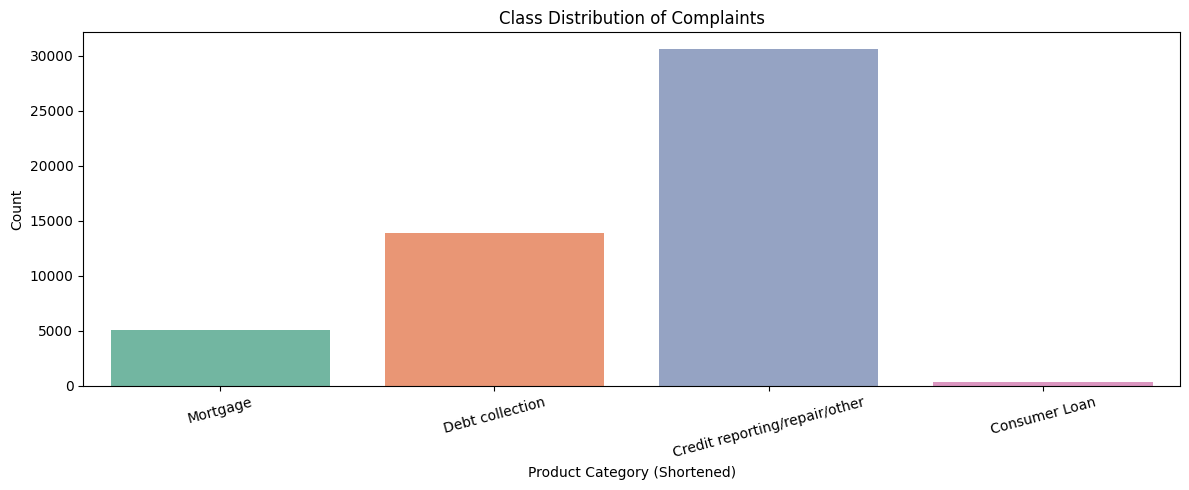

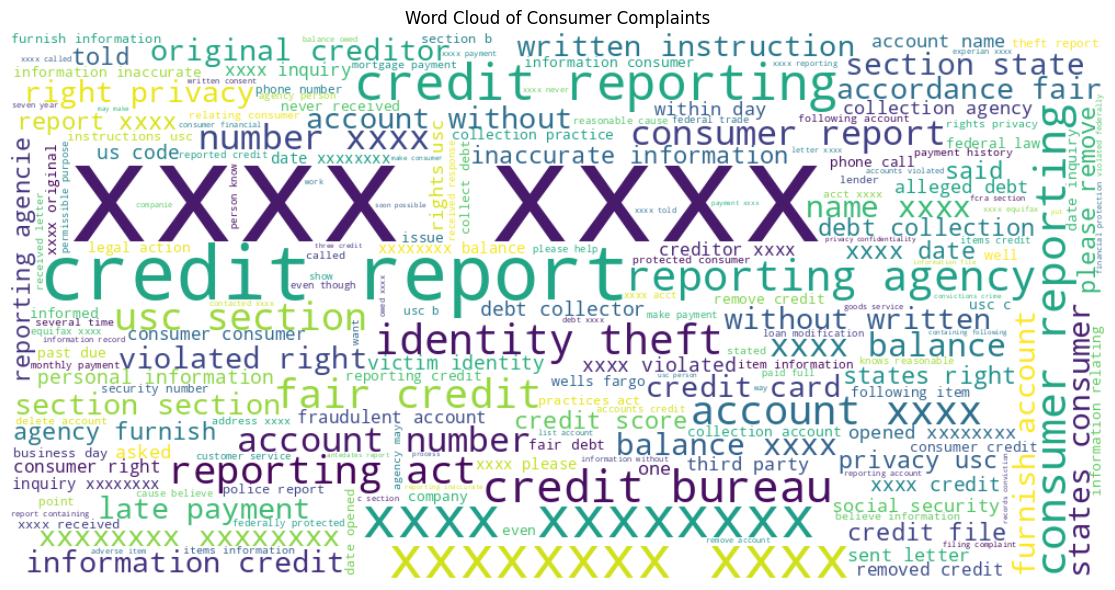

In [8]:
label_map_short = {
    'Credit reporting, credit repair services, or other personal consumer reports': 'Credit reporting/repair/other',
    'Debt collection': 'Debt collection',
    'Consumer Loan': 'Consumer Loan',
    'Mortgage': 'Mortgage'
}

data_small['Product_short'] = data_small['Product'].map(label_map_short)

# Class distribution plot
plt.figure(figsize=(12,5))
sns.countplot(x=data_small['Product_short'], palette='Set2')
plt.title("Class Distribution of Complaints")
plt.xlabel("Product Category (Shortened)")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# WordCloud visualization 
text_all = ' '.join(data_small['clean_text'].tolist())
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text_all)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Consumer Complaints")
plt.tight_layout()
plt.show()


In [9]:
X = data_small['clean_text']
y = data_small['label']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))


Training Samples: 40000
Testing Samples: 10000


# Feature Engineering

In [10]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Selection of Multi Classification model, Comparison of model performance


Logistic Regression Accuracy: 0.8930

Naive Bayes Accuracy: 0.8650

Random Forest Accuracy: 0.8959


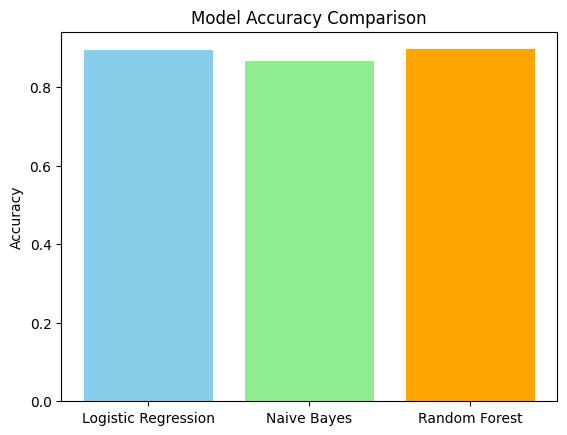

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{name} Accuracy: {acc:.4f}")

plt.bar(results.keys(), results.values(), color=['skyblue','lightgreen','orange'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Model Evaluation

Best Model: Random Forest

Classification Report:
                                                                              precision    recall  f1-score   support

Credit reporting, credit repair services, or other personal consumer reports       0.90      0.95      0.93      6122
                                                             Debt collection       0.88      0.80      0.84      2790
                                                               Consumer Loan       0.00      0.00      0.00        71
                                                                    Mortgage       0.90      0.88      0.89      1017

                                                                    accuracy                           0.90     10000
                                                                   macro avg       0.67      0.66      0.66     10000
                                                                weighted avg       0.89      0.90      0.89     10000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


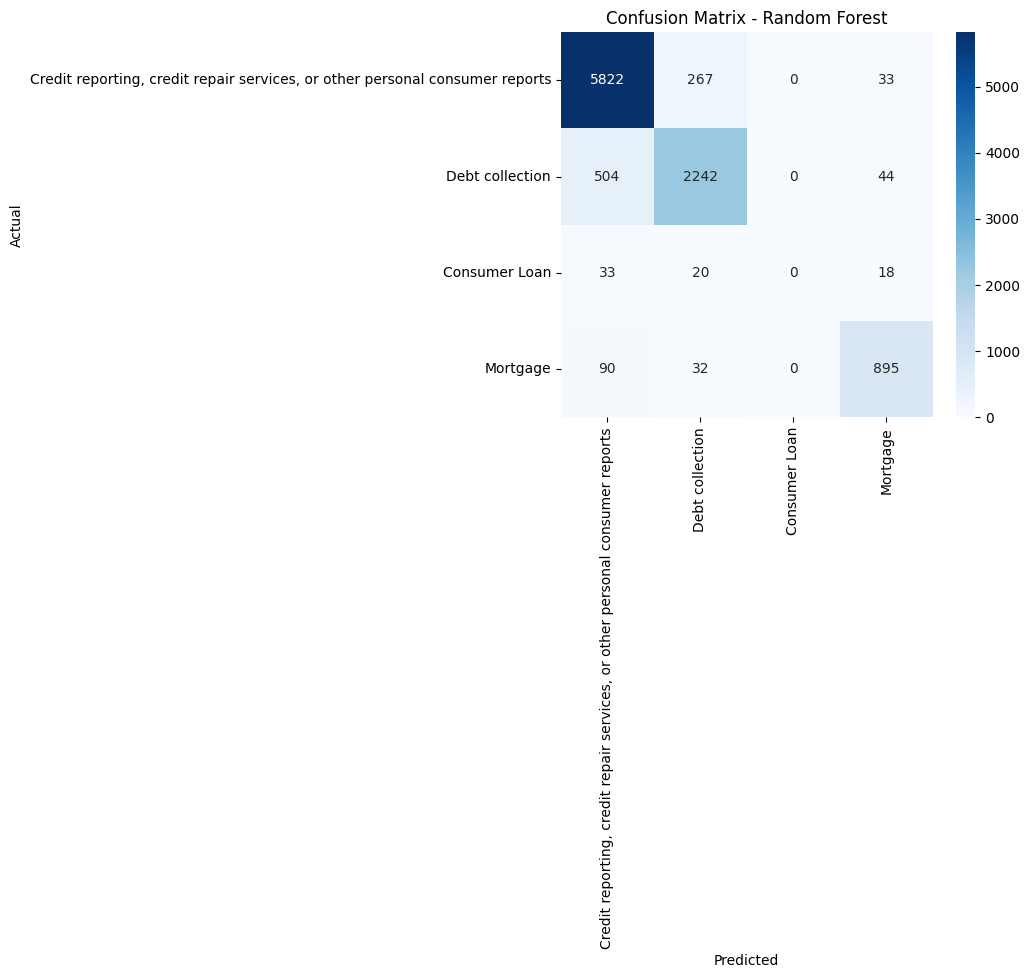

In [16]:
# Pick best model
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

best_model = models[best_model_name]
y_pred = best_model.predict(X_test_tfidf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=selected))

# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=selected, yticklabels=selected, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Prediction  

In [17]:
sample_texts = [
    "My credit report has incorrect information that I cannot remove.",
    "Debt collector keeps calling even after payment.",
    "Loan payment schedule was not communicated properly.",
    "Mortgage company mishandled my escrow account."
]

sample_clean = [clean_text(t) for t in sample_texts]
sample_tfidf = vectorizer.transform(sample_clean)
preds = best_model.predict(sample_tfidf)

print("\n--- Sample Predictions ---")
for t, p in zip(sample_texts, preds):
    print(f"{t} --> Predicted Category: {selected[p]}")


--- Sample Predictions ---
My credit report has incorrect information that I cannot remove. --> Predicted Category: Credit reporting, credit repair services, or other personal consumer reports
Debt collector keeps calling even after payment. --> Predicted Category: Debt collection
Loan payment schedule was not communicated properly. --> Predicted Category: Mortgage
Mortgage company mishandled my escrow account. --> Predicted Category: Mortgage
